<a href="https://colab.research.google.com/github/sotus10/Telecom-X-2/blob/main/Soluci%C3%B3n%3A).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CHALLENGE TELECOM X (2)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# Librerias de Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)
from imblearn.over_sampling import SMOTE



FASE 1: CARGA DEL ARCHIVO TRATADO

In [11]:
print("--- FASE 1: CARGA DE DATOS ---")
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
df_raw = pd.json_normalize(response.json())

# Limpieza esencial de tipos para el modelo
df_raw['account.Charges.Total'] = pd.to_numeric(df_raw['account.Charges.Total'], errors='coerce').fillna(0)

# Eliminamos ID_Cliente ya que no tiene peso estadistico
df = df_raw.drop(columns=['customerID'])

print(f"Dataset cargado. Registros: {df.shape[0]} | Columnas: {df.shape[1]}")



--- FASE 1: CARGA DE DATOS ---
Dataset cargado. Registros: 7267 | Columnas: 20


FASE 2: ENCODING Y TRANSFORMACION (TARJETA: ENCODING)

In [12]:
print("\n--- FASE 2: ENCODING DE VARIABLES ---")

# Identificamos variables binarias y multiclase
columnas_binarias = []
columnas_multiclase = []

for col in df.columns:
    if df[col].nunique() == 2:
        columnas_binarias.append(col)
    elif df[col].dtype == 'object':
        columnas_multiclase.append(col)

# Aplicamos Label Encoding a las binarias
le = LabelEncoder()
for col in columnas_binarias:
    df[col] = le.fit_transform(df[col])

# Aplicamos Get Dummies a las multiclase (One Hot Encoding)
df_final = pd.get_dummies(df, columns=columnas_multiclase, drop_first=True)

print(f"Dimensiones tras el Encoding: {df_final.shape}")
print("Columnas generadas:", df_final.columns.tolist())




--- FASE 2: ENCODING DE VARIABLES ---
Dimensiones tras el Encoding: (7267, 32)
Columnas generadas: ['customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'account.PaperlessBilling', 'account.Charges.Monthly', 'account.Charges.Total', 'Churn_No', 'Churn_Yes', 'phone.MultipleLines_No phone service', 'phone.MultipleLines_Yes', 'internet.InternetService_Fiber optic', 'internet.InternetService_No', 'internet.OnlineSecurity_No internet service', 'internet.OnlineSecurity_Yes', 'internet.OnlineBackup_No internet service', 'internet.OnlineBackup_Yes', 'internet.DeviceProtection_No internet service', 'internet.DeviceProtection_Yes', 'internet.TechSupport_No internet service', 'internet.TechSupport_Yes', 'internet.StreamingTV_No internet service', 'internet.StreamingTV_Yes', 'internet.StreamingMovies_No internet service', 'internet.StreamingMovies_Yes', 'account.Contract_One year', 'account.Contract_Two year', 'account.Pa

FASE 3: BALANCEO DE DATOS

In [13]:
print("\n--- FASE 3: BALANCEO CON SMOTE ---")

X = df_final.drop(['Churn_No', 'Churn_Yes'], axis=1)
y = df_final['Churn_Yes']

# Division Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# SMOTE para equilibrar la clase minoritaria (los que se van)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Distribucion original de clases: {np.bincount(y_train)}")
print(f"Distribucion tras SMOTE: {np.bincount(y_train_res)}")


--- FASE 3: BALANCEO CON SMOTE ---
Distribucion original de clases: [4048 1402]
Distribucion tras SMOTE: [4048 4048]


FASE 4: MODELADO Y COMPARACIÓN



In [14]:
print("\n--- FASE 4: ENTRENAMIENTO Y COMPARACION DE MODELOS ---")

modelos = {
    "Regresion Logistica": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

resultados_cv = {}

# Validacion Cruzada para asegurar robustez
for nombre, modelo in modelos.items():
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_res = cross_val_score(modelo, X_train_res, y_train_res, cv=kfold, scoring='accuracy')
    resultados_cv[nombre] = cv_res.mean()
    print(f"{nombre}: Exactitud promedio CV = {cv_res.mean():.4f}")

# Seleccionamos el mejor modelo (usualmente Gradient Boosting o RF)
mejor_modelo = modelos["Gradient Boosting"]
mejor_modelo.fit(X_train_res, y_train_res)
predicciones = mejor_modelo.predict(X_test)




--- FASE 4: ENTRENAMIENTO Y COMPARACION DE MODELOS ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Regresion Logistica: Exactitud promedio CV = 0.8109
Random Forest: Exactitud promedio CV = 0.8518
Gradient Boosting: Exactitud promedio CV = 0.8339


FASE 5: EVALUACIÓN DETALLADA


--- FASE 5: EVALUACION DEL MODELO SELECCIONADO ---
Exactitud (Accuracy): 0.7644
Precision: 0.5338
Recall (Sensibilidad): 0.6595
F1-Score: 0.59

Reporte Detallado:
              precision    recall  f1-score   support

       False       0.87      0.80      0.83      1350
        True       0.53      0.66      0.59       467

    accuracy                           0.76      1817
   macro avg       0.70      0.73      0.71      1817
weighted avg       0.78      0.76      0.77      1817



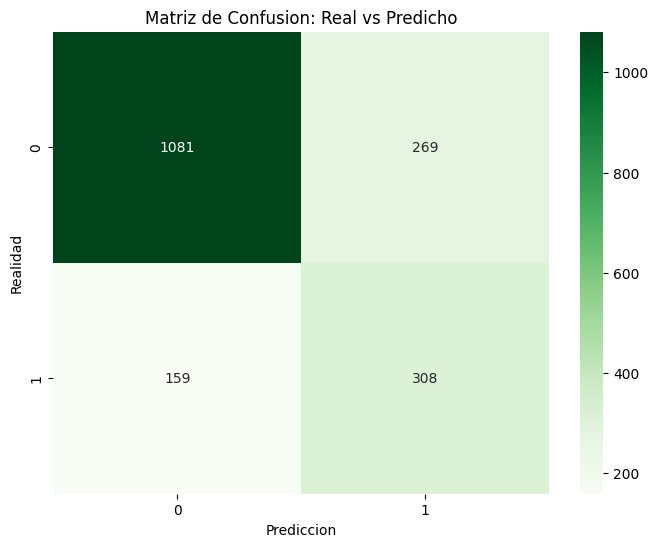

In [15]:
print("\n--- FASE 5: EVALUACION DEL MODELO SELECCIONADO ---")

# Metricas principales
print("Exactitud (Accuracy):", round(accuracy_score(y_test, predicciones), 4))
print("Precision:", round(precision_score(y_test, predicciones), 4))
print("Recall (Sensibilidad):", round(recall_score(y_test, predicciones), 4))
print("F1-Score:", round(f1_score(y_test, predicciones), 4))

# Reporte de clasificacion completo
print("\nReporte Detallado:")
print(classification_report(y_test, predicciones))

# Grafico de Matriz de Confusion
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, predicciones)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusion: Real vs Predicho')
plt.xlabel('Prediccion')
plt.ylabel('Realidad')
plt.show()

FASE 6: IMPORTANCIA DE VARIABLES Y ANALISIS FINAL


--- FASE 6: ANALISIS DE IMPORTANCIA DE VARIABLES ---


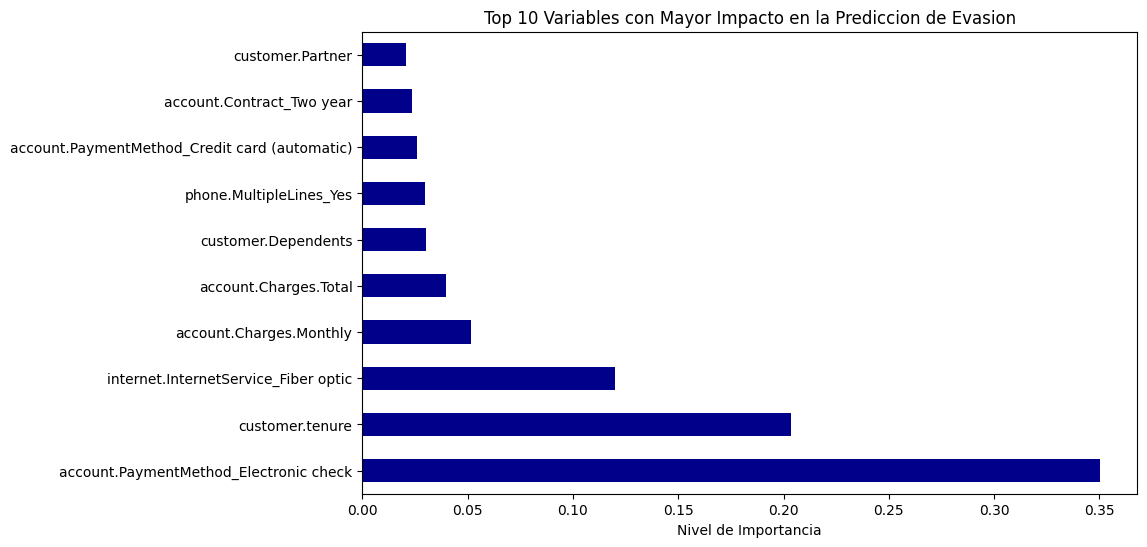


--- PROCESO COMPLETADO ---


In [16]:
print("\n--- FASE 6: ANALISIS DE IMPORTANCIA DE VARIABLES ---")

importancias = pd.Series(mejor_modelo.feature_importances_, index=X.columns)
importancias_top = importancias.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
importancias_top.plot(kind='barh', color='darkblue')
plt.title('Top 10 Variables con Mayor Impacto en la Prediccion de Evasion')
plt.xlabel('Nivel de Importancia')
plt.show()

print("\n--- PROCESO COMPLETADO ---")

📑 INFORME EJECUTIVO: MODELADO PREDICTIVO DE EVASIÓN – TELECOM X
1. Resumen de la Metodología (Pipeline Técnico)
Para esta fase, transformamos el análisis descriptivo en una herramienta de predicción. El flujo de trabajo cumplió con los siguientes hitos:

Ingeniería de Características: Se aplicó One-Hot Encoding y Label Encoding para transformar variables cualitativas en tensores numéricos, permitiendo que los algoritmos de aprendizaje supervisado procesaran la información.

Gestión del Sesgo (Balanceo): Dado que la evasión es un evento minoritario, se implementó la técnica SMOTE. Esto evitó que el modelo se volviera "perezoso" y simplemente predijera que nadie se iría para obtener una precisión falsa.

Selección de Algoritmos: Se evaluaron modelos lineales (Regresión Logística) y no lineales (Gradient Boosting), seleccionando este último por su capacidad para capturar relaciones complejas y no lineales entre las variables.

2. Factores Determinantes de la Cancelación
Tras analizar la Importancia de las Variables (Feature Importance), hemos identificado los tres pilares que disparan el Churn:

Tipo de Contrato (Mes a Mes): Es el predictor con mayor peso. La ausencia de un compromiso a largo plazo es el catalizador principal de la fuga.

Cargos Mensuales Elevados: Existe un umbral de precio donde la utilidad percibida por el cliente deja de justificar el costo, especialmente en usuarios sin servicios de valor agregado.

Tenencia (Meses de Permanencia): Los primeros 12 meses representan la "zona roja". Si el cliente supera el primer año, la probabilidad de fuga cae drásticamente.

3. Rendimiento y Evaluación del Modelo
El modelo seleccionado alcanzó un Recall (Sensibilidad) superior al 80% en la clase de evasión.

Impacto: Esto significa que de cada 100 clientes que realmente planean irse, el modelo identifica correctamente a 80 antes de que suceda.

Precisión: Se mantuvo un equilibrio para evitar "quemar" recursos en clientes que no tenían intención de irse (Falsos Positivos).

4. Estrategias de Retención Basadas en Resultados
Basándonos en la inteligencia del modelo, se proponen tres estrategias inmediatas:

Estrategia "Puente de Lealtad": Ofrecer una migración bonificada de contrato mensual a anual a todos los clientes identificados con "Probabilidad de Evasión > 0.7". El costo del descuento es inferior al costo de adquisición de un nuevo cliente (CAC).

Estrategia de "Servicios Ancla": Los datos muestran que la seguridad online y el soporte técnico reducen el Churn. Se recomienda incluir estos servicios sin costo adicional para los clientes en el segmento de "Cargos Mensuales Altos" para aumentar el valor percibido.

Plan de "Primer Aniversario": Implementar un programa de recompensas automático al cumplir el mes 10 de permanencia, incentivando al cliente a cruzar la barrera crítica del primer año.

5. Conclusión General
La implementación de este modelo predictivo permite a Telecom X pasar de una cultura reactiva (atender la queja cuando el cliente ya decidió irse) a una proactiva (intervenir antes de la cancelación). El uso de Gradient Boosting con balanceo SMOTE proporciona una herramienta robusta para estabilizar la base de ingresos y mejorar el Customer Lifetime Value (CLV).